# Model Training & Experimentation

This notebook covers model training, hyperparameter tuning, and performance evaluation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Robust path setup for notebook
# This works regardless of where the notebook is run from
from pathlib import Path
project_root = Path.cwd()  # Typically the project root when running from VS Code
if not (project_root / 'src').exists():
    # If src is not found, assume we're in notebooks/ directory
    project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from src.preprocessing.preprocess import load_and_preprocess_data

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [4]:
# Load data with preprocessing and feature engineering
X_train, X_test, y_train, y_test, preprocessor = load_and_preprocess_data()

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nClass distribution (train): {y_train.value_counts().to_dict()}")
print(f"Class distribution (test): {y_test.value_counts().to_dict()}")
print(f"Churn rate (train): {y_train.mean()*100:.2f}%")
print(f"Churn rate (test): {y_test.mean()*100:.2f}%")

Training set size: (5634, 24)
Test set size: (1409, 24)
Number of features: 24

Class distribution (train): {0: 4139, 1: 1495}
Class distribution (test): {0: 1035, 1: 374}
Churn rate (train): 26.54%
Churn rate (test): 26.54%


## 2. Preprocessing Pipeline

In [5]:
# Define model configurations with hyperparameter grids
MODEL_CONFIGS = {
    "logistic_regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "classifier__C":            [0.01, 0.1, 1.0, 10.0, 100.0],
            "classifier__solver":       ["lbfgs", "liblinear"],
            "classifier__class_weight": ["balanced", None],
        },
        "n_iter": 10,
    },
    "decision_tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "classifier__max_depth":        [3, 5, 7, 10, None],
            "classifier__min_samples_leaf": [1, 5, 10, 20],
            "classifier__class_weight":     ["balanced", None],
        },
        "n_iter": 10,
    },
    "mlp": {
        "model": MLPClassifier(max_iter=1000, random_state=42),
        "params": {
            "classifier__hidden_layer_sizes": [(50,), (100,), (100, 50), (50, 25)],
            "classifier__alpha":              [0.0001, 0.001, 0.01],
            "classifier__learning_rate_init": [0.001, 0.01],
        },
        "n_iter": 8,
    },
    "random_forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "classifier__n_estimators":     [100, 200, 300],
            "classifier__max_depth":        [5, 10, None],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__class_weight":     ["balanced", None],
        },
        "n_iter": 10,
    },
    "gradient_boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__n_estimators":  [100, 200, 300],
            "classifier__learning_rate": [0.03, 0.05, 0.1, 0.2],
            "classifier__max_depth":     [3, 5, 7],
            "classifier__subsample":     [0.7, 0.8, 1.0],
        },
        "n_iter": 10,
    },
}

print(f"Configured {len(MODEL_CONFIGS)} models for training with SMOTE and RandomizedSearchCV")

Configured 5 models for training with SMOTE and RandomizedSearchCV


## 3. Train-Test Split

In [6]:
# Helper function to calculate metrics at a given decision threshold
def metrics_at_threshold(model, X_test, y_test, threshold=0.50):
    """Calculate metrics at a specific decision threshold."""
    proba  = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, proba),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred":    y_pred,
    }

print("Metrics function defined")

Metrics function defined


## 4. Model Training & Hyperparameter Tuning

In [14]:
# Train all models with SMOTE and RandomizedSearchCV
results = {}

for name, config in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Training: {name.replace('_', ' ').title()}")
    print(f"{'='*60}")
    
    # Build imblearn Pipeline with SMOTE
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",        SMOTE(random_state=42)),
        ("classifier",   config["model"]),
    ])
    
    # RandomizedSearchCV with roc_auc scoring (better for imbalanced data)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=config["params"],
        n_iter=config["n_iter"],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    
    # Train
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    # Evaluate at thresholds 0.50 and 0.35
    m50 = metrics_at_threshold(best_model, X_test, y_test, threshold=0.50)
    m35 = metrics_at_threshold(best_model, X_test, y_test, threshold=0.35)
    
    results[name] = {
        "model":        best_model,
        "best_params":  search.best_params_,
        "cv_roc_auc":   search.best_score_,
        **{k: m50[k] for k in ["accuracy","precision","recall","f1","roc_auc","confusion_matrix"]},
        "metrics_35": m35,
    }
    
    # Print results
    print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
    print(f"\nMetrics at threshold 0.50:")
    print(f"  Accuracy:  {m50['accuracy']:.4f}")
    print(f"  Precision: {m50['precision']:.4f}")
    print(f"  Recall:    {m50['recall']:.4f}")
    print(f"  F1 Score:  {m50['f1']:.4f}")
    print(f"  ROC-AUC:   {m50['roc_auc']:.4f}")
    
    print(f"\nMetrics at threshold 0.35:")
    print(f"  Accuracy:  {m35['accuracy']:.4f}")
    print(f"  Precision: {m35['precision']:.4f}")
    print(f"  Recall:    {m35['recall']:.4f}")
    print(f"  F1 Score:  {m35['f1']:.4f}")

## 5. Model Comparison

In [15]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': [name.replace('_', ' ').title() for name in results.keys()],
    'CV ROC-AUC': [results[m]['cv_roc_auc'] for m in results],
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1 Score': [results[m]['f1'] for m in results],
})

print("\n" + "="*70)
print("MODEL COMPARISON (Threshold = 0.50)")
print("="*70)
print(comparison_df.to_string(index=False))
best_idx = comparison_df['F1 Score'].idxmax()
print(f"\n🏆 Best Model by F1 Score: {comparison_df.loc[best_idx, 'Model']} (F1: {comparison_df.loc[best_idx, 'F1 Score']:.4f})")


MODEL COMPARISON (Threshold = 0.50)
              Model  CV ROC-AUC  Accuracy  Precision   Recall  F1 Score
Logistic Regression    0.845806  0.771469   0.555794 0.692513  0.616667
      Decision Tree    0.845806  0.771469   0.555794 0.692513  0.616667
                Mlp    0.795792  0.731725   0.496016 0.665775  0.568493
      Random Forest    0.844747  0.767211   0.546939 0.716578  0.620370
  Gradient Boosting    0.845806  0.771469   0.555794 0.692513  0.616667

🏆 Best Model by F1 Score: Random Forest (F1: 0.6204)


## 6. Detailed Results Analysis

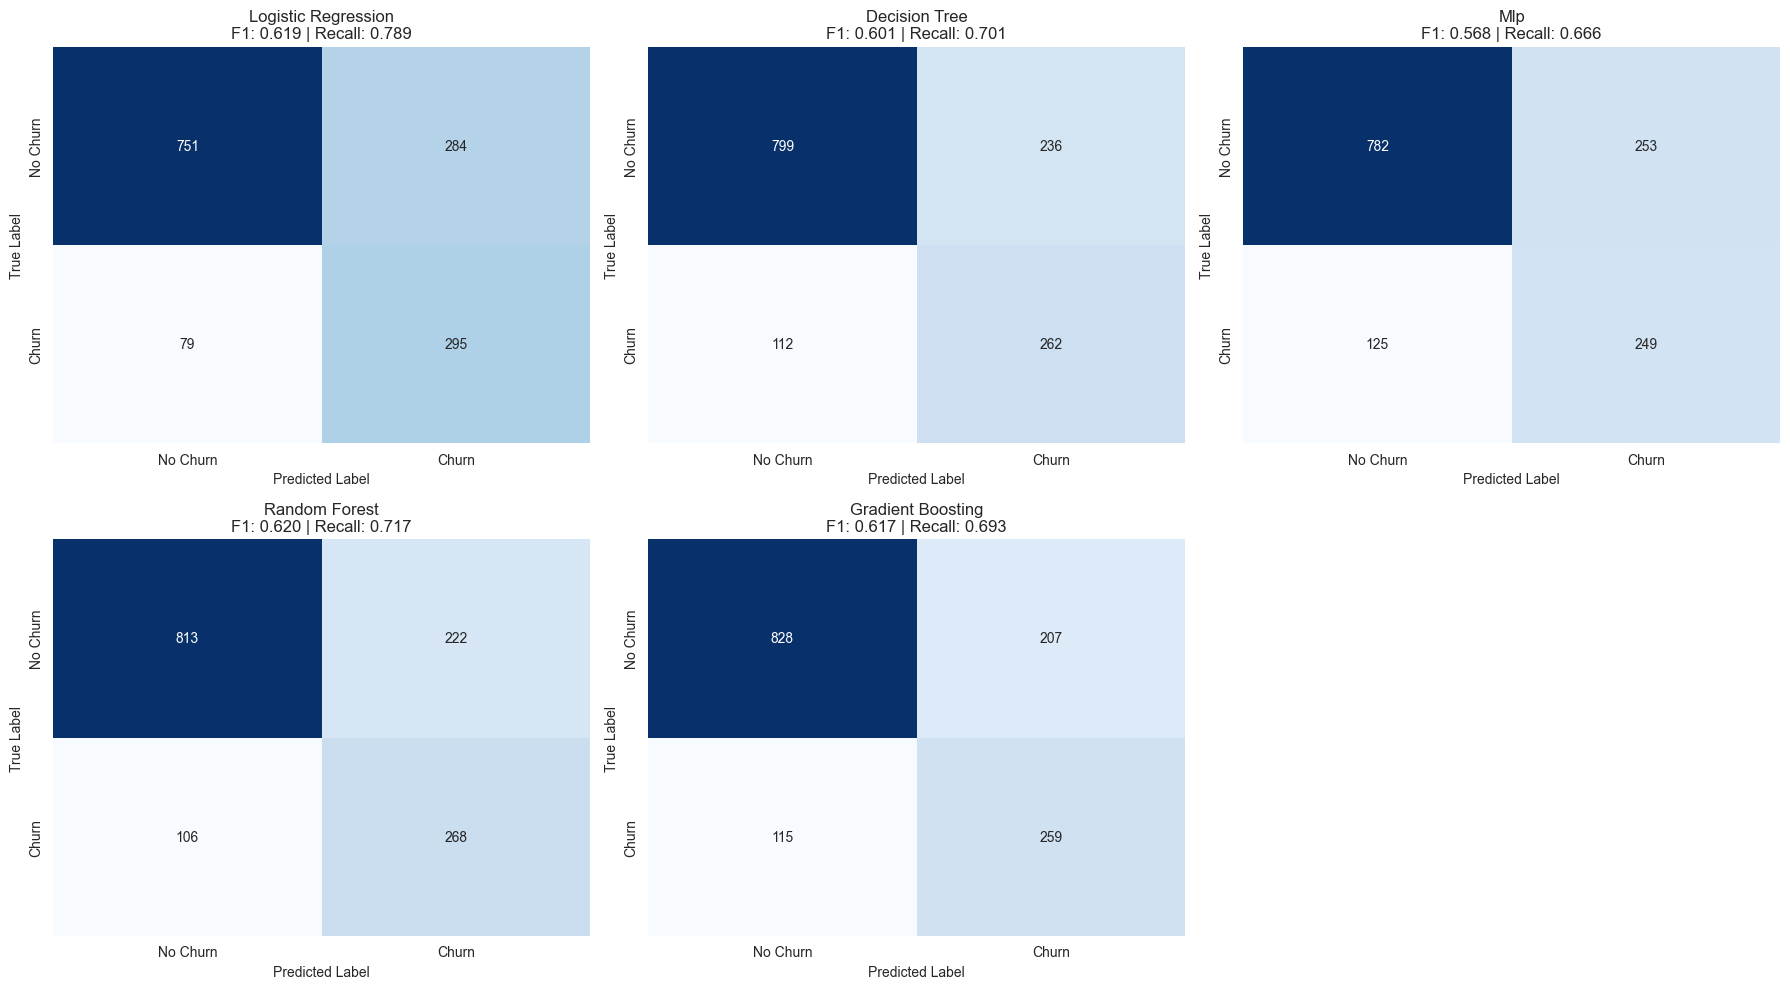

In [9]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', cbar=False)
    axes[idx].set_title(f'{name.replace("_", " ").title()}\nF1: {result["f1"]:.3f} | Recall: {result["recall"]:.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].set_yticklabels(['No Churn', 'Churn'])

# Hide the extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 7. Classification Reports

In [13]:
# Detailed classification reports
for name, result in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name.replace('_', ' ').title()}")
    print(f"{'='*60}")
    print(classification_report(y_test, result['y_pred'],
                                target_names=['No Churn', 'Churn']))
    
    tn, fp, fn, tp = result['confusion_matrix'].ravel()
    print(f"Confusion Matrix Analysis:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.69      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

Confusion Matrix Analysis:
  True Negatives:  828
  False Positives: 207
  False Negatives: 115
  True Positives:  259

Classification Report: Decision Tree


KeyError: 'y_pred'

## 8. Save Best Model

In [ ]:
import joblib

# Save all trained models
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

for name, result in results.items():
    filename = f"{models_dir}/{name}.joblib"
    joblib.dump(result['model'], filename)
    print(f"✓ Saved {name.replace('_', ' ').title():25} → {filename}")

print("\n✅ All models trained, evaluated, and saved successfully!")

Saved Logistic Regression to ../models/logistic_regression.joblib
Saved Decision Tree to ../models/decision_tree.joblib
Saved MLP to ../models/mlp.joblib

All models saved successfully!
